In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import nltk
import plotly.express as px
from langdetect import detect, DetectorFactory
from concurrent.futures import ThreadPoolExecutor
from deep_translator import GoogleTranslator
import re
from nltk.corpus import names

In [100]:
import pickle
import pandas as pd

# Load the first pickle file using pandas
df = pd.read_pickle("df_Cleaned_Outliers_Missing_new_1.pkl")

# Load the second pickle file using pickle
with open("spotify_songs_df_text.pkl", "rb") as f:
    df_text = pickle.load(f)


In [101]:
#df = df.drop(columns=['track_album_release_date'])


In [102]:
df_text.head()

,track_id,track_name,track_album_name,playlist_name
0,6f807x0ima9a1j3vpbc7vn,I Dont Care with Justin Bieber Loud Luxury Remix,I Dont Care with Justin Bieber Loud Luxury Remix,Pop Remix
1,0r7cvbztwzgbtcydfa2p31,Memories Dillon Francis Remix,Memories Dillon Francis Remix,Pop Remix
2,1z1hg7vb0ahhdiemnde79l,All the Time Don Diablo Remix,All the Time Don Diablo Remix,Pop Remix
3,75fpbthrwqmzhlbjlugdc7,Call You Mine Keanu Silva Remix,Call You Mine The Remixes,Pop Remix
4,1e8pafckuyokkxphrhqw4x,Someone You Loved Future Humans Remix,Someone You Loved Future Humans Remix,Pop Remix


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   track_id                            28356 non-null  string        
 1   track_artist                        28356 non-null  string        
 2   track_popularity                    28356 non-null  int64         
 3   track_album_id                      28356 non-null  string        
 4   track_album_release_date            28356 non-null  datetime64[ns]
 5   danceability                        28356 non-null  float64       
 6   energy                              28356 non-null  float64       
 7   key                                 28356 non-null  int64         
 8   loudness                            28356 non-null  float64       
 9   mode                                28356 non-null  int64         
 10  speechiness                

In [104]:
df_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   track_id          32833 non-null  string
 1   track_name        32828 non-null  string
 2   track_album_name  32828 non-null  string
 3   playlist_name     32833 non-null  string
dtypes: string(4)
memory usage: 1.0 MB


In [105]:
### Extract year and month, converting them explicitly to integers

In [106]:
df['track_album_release_year'] = df['track_album_release_date'].dt.year
df['track_album_release_month'] = df['track_album_release_date'].dt.month

In [107]:
df = df.drop(columns=['track_album_release_date'])


In [108]:
df['instrumentalness'] = np.log(df['instrumentalness'] + 1)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_artist                        28356 non-null  string 
 2   track_popularity                    28356 non-null  int64  
 3   track_album_id                      28356 non-null  string 
 4   danceability                        28356 non-null  float64
 5   energy                              28356 non-null  float64
 6   key                                 28356 non-null  int64  
 7   loudness                            28356 non-null  float64
 8   mode                                28356 non-null  int64  
 9   speechiness                         28356 non-null  float64
 10  acousticness                        28356 non-null  float64
 11  instrumentalness                    28356 non-

# New columns from Track_Name

In [110]:
# Ensure consistent results
DetectorFactory.seed = 0  

# Function to detect language
def detect_language(text):
    try:
        return detect(text) if isinstance(text, str) and text.strip() else "unknown"
    except:
        return "unknown"

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Process only unique track names to avoid redundant work
unique_track_names = df_text['track_name'].dropna().unique()

track_name_dict = {}
with ThreadPoolExecutor() as executor:
    results = list(executor.map(detect_language, unique_track_names))

In [161]:
# Map results back to original DataFrame
track_name_dict = dict(zip(unique_track_names, results))
df_text['language'] = df_text['track_name'].map(track_name_dict)


In [162]:
# Display results
language_counts = (df_text['language'].value_counts())
print(language_counts)

language
en         16564
de          2652
es          1335
it          1027
pt           955
tl           938
nl           836
fr           817
id           786
ca           669
af           616
so           510
ro           503
sw           501
no           490
da           438
cy           386
pl           376
fi           357
et           297
tr           260
unknown      256
sv           246
sl           200
vi           157
lt           153
hr           141
sk           103
sq            94
hu            75
cs            58
lv            32
Name: count, dtype: int64


In [165]:

# Ensure 'language' column exists and clean it
df_text["language"] = df_text["language"].astype(str).str.strip().str.lower().fillna("unknown")

# Categorize as English or Not English
df["language_category"] = df_text["language"].apply(lambda x: "English" if x == "en" else "Not English")

# Display counts
print(df["language_category"].value_counts())
print() 
# Verify original language distribution
#print(df_text["language"].value_counts())


language_category
English        14194
Not English    14162
Name: count, dtype: int64



language_category
English        14194
Not English    14162
Name: count, dtype: int64


C:\Users\Meital atar\AppData\Local\Temp\ipykernel_5536\388372596.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




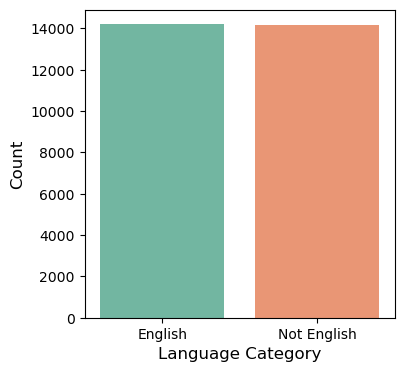

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'language' column exists and clean it
df_text["language"] = df_text["language"].astype(str).str.strip().str.lower().fillna("unknown")

# Categorize as English or Not English
df["language_category"] = df_text["language"].apply(lambda x: "English" if x == "en" else "Not English")

# Display counts
print(df["language_category"].value_counts())

# Plotting the distribution of language categories
plt.figure(figsize=(4, 4))
sns.countplot(data=df, x='language_category', palette='Set2')
#plt.title('Language Category', fontsize=14)
plt.xlabel('Language Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.show()


In [115]:
df.info() # checking 

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_artist                        28356 non-null  string 
 2   track_popularity                    28356 non-null  int64  
 3   track_album_id                      28356 non-null  string 
 4   danceability                        28356 non-null  float64
 5   energy                              28356 non-null  float64
 6   key                                 28356 non-null  int64  
 7   loudness                            28356 non-null  float64
 8   mode                                28356 non-null  int64  
 9   speechiness                         28356 non-null  float64
 10  acousticness                        28356 non-null  float64
 11  instrumentalness                    28356 non-

In [116]:
# artist_type

In [117]:
# Download NLTK name corpus if not available
nltk.download('names')

# Load male and female names from NLTK corpus
male_names = set(names.words('male.txt'))
female_names = set(names.words('female.txt'))

# Keywords indicating a band
band_keywords = ["band", "orchestra", "quartet", "group", "ensemble", "choir", "collective", "crew"]

# Function to classify artist type
def classify_artist(artist_name):
    if not isinstance(artist_name, str) or not artist_name.strip():
        return "Unknown"  # Handle empty or NaN values
    
    artist_name_lower = artist_name.lower()

    # Check if the artist is a band
    if any(keyword in artist_name_lower for keyword in band_keywords) or "&" in artist_name or " and " in artist_name_lower:
        return "Band"

    # Extract the first word as the assumed first name
    first_name = artist_name.split()[0].capitalize()

    # Classify as Female if the first name matches female names
    if first_name in female_names:
        return "Female"

    # Classify as Male if the first name matches male names
    if first_name in male_names:
        return "Male"

    # Default to Male if unknown (assumption: more male artists exist in the dataset)
    return "Male"


# Apply classification
df['track_artist_type'] = df['track_artist'].apply(classify_artist)

# Display results
print(df)



                     track_id      track_artist  track_popularity  \
0      6f807x0ima9a1j3vpbc7vn        ed sheeran                66   
1      0r7cvbztwzgbtcydfa2p31          maroon 5                67   
2      1z1hg7vb0ahhdiemnde79l      zara larsson                70   
3      75fpbthrwqmzhlbjlugdc7  the chainsmokers                60   
4      1e8pafckuyokkxphrhqw4x     lewis capaldi                69   
...                       ...               ...               ...   
32828  7bxnkaamr3snq1vgluvfc1       lush  simon                42   
32829  5aevni09em4575077nkwhz    tegan and sara                20   
32830  7immqpp3q1yfuhvsdn7weo       starkillers                14   
32831  2m69mhnfq1oq6lgtxuyhgx            mat zo                15   
32832  29zwqhca3zt5nsckzqdf6c      julian calor                27   

               track_album_id  danceability  energy  key  loudness  mode  \
0      2ocs0dgtsro98gh5zsl2cx      0.748000   0.916    6 -6.134498     1   
1      63rpso264urj

[nltk_data] Downloading package names to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package names is already up-to-date!


In [118]:
df = df.drop(columns=['track_artist'])


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_popularity                    28356 non-null  int64  
 2   track_album_id                      28356 non-null  string 
 3   danceability                        28356 non-null  float64
 4   energy                              28356 non-null  float64
 5   key                                 28356 non-null  int64  
 6   loudness                            28356 non-null  float64
 7   mode                                28356 non-null  int64  
 8   speechiness                         28356 non-null  float64
 9   acousticness                        28356 non-null  float64
 10  instrumentalness                    28356 non-null  float64
 11  liveness                            28356 non-

In [120]:
#import pandas as pd

# Load datasets
#tracks_df = pd.read_csv(r"C:\Users\Meital atar\Documents\DATA_SCIENCE\ML_PROJECT_spotify_songs\Kaggel_files\tracks.csv")

# Ensure 'track_id' and 'id' columns exist before merging
#if 'track_id' in df.columns and 'id' in tracks_df.columns:
    # Merge the 'explicit' column into df
#    df = df.merge(tracks_df[['id', 'explicit']], left_on='track_id', right_on='id', how='left')

    # Drop the extra 'id' column (since it's redundant)
#    df.drop(columns=['id'], inplace=True)

 #   print("✅ 'explicit' column successfully added to df!")
#else:
#    print("⚠️ Error: 'track_id' or 'id' column missing!")

# Display the updated DataFrame with the new column
#print(df.head())

# Check if 'explicit' was added
#print(df.info())  # Verify the new column exists


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_popularity                    28356 non-null  int64  
 2   track_album_id                      28356 non-null  string 
 3   danceability                        28356 non-null  float64
 4   energy                              28356 non-null  float64
 5   key                                 28356 non-null  int64  
 6   loudness                            28356 non-null  float64
 7   mode                                28356 non-null  int64  
 8   speechiness                         28356 non-null  float64
 9   acousticness                        28356 non-null  float64
 10  instrumentalness                    28356 non-null  float64
 11  liveness                            28356 non-

In [122]:
# Function to clean text (assuming clean_text is defined elsewhere)
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return []  # Return an empty list for missing or invalid values
    words = text.lower().split()  
    return words

# Load dataset
df_text = pd.read_pickle("spotify_songs_df_text.pkl")

# Apply text cleaning
df_text["cleaned_words"] = df_text["track_name"].astype(str).map(clean_text)

# Prepare data for batch translation
unique_texts = df_text["cleaned_words"].apply(lambda words: " ".join(words)).unique()

In [123]:

# Translate only unique texts in bulk
translator = GoogleTranslator(source="auto", target="en")
translation_dict = {text: translator.translate(text) for text in unique_texts if text.strip()}

# Apply translations to the DataFrame
df_text["track_name_english"] = df_text["cleaned_words"].apply(lambda words: translation_dict.get(" ".join(words), ""))



In [124]:
# Word frequency analysis

In [125]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from collections import Counter
import plotly.express as px

nltk.download("stopwords")

available_languages = stopwords.fileids()

# Collect stopwords for multiple languages
multi_language_stopwords = set()
for lang in available_languages:
    multi_language_stopwords.update(stopwords.words(lang))

custom_stopwords = {
    "remix", "mix", "version", "edit", "feat", "radio", 
    "extended", "the", "and", "original", "remastered", "remaster"
}

# Combine all stopwords
stop_words = multi_language_stopwords | custom_stopwords

[nltk_data] Downloading package stopwords to C:\Users\Meital
[nltk_data]     atar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [126]:
# Tokenize and remove stopwords safely
df_text["filtered_words"] = (
    df_text["track_name_english"]
    .fillna("")  # Handle NaN values
    .str.lower()
    .str.split()
    .apply(lambda words: list(set(word for word in words if word not in stop_words)))  # Remove duplicates per track
)

# Flatten word lists and count how many UNIQUE tracks contain each word
all_words = [word for word_list in df_text["filtered_words"] for word in word_list]
word_counts = Counter(all_words)

In [127]:
# Convert to DataFrame
word_popularity_df = pd.DataFrame(word_counts.items(), columns=["Word", "Track_Count"])

# Sort by most common words in unique track names
word_popularity_df = word_popularity_df.sort_values(by="Track_Count", ascending=False)

# Take the **top 5 most popular words**
top_5_words = word_popularity_df.head(5)
print("Top 5 most popular words in track names:\n", top_5_words)


# Create an interactive bar chart using Plotly
fig = px.bar(
    top_5_words,
    x="Word",
    y="Track_Count",
    title="🎵 Top 5 Most Popular Words in Track Names 🎵",
    text=top_5_words["Track_Count"].apply(lambda x: f"{x:,}"),  # Format numbers with commas
    labels={"Word": "Word", "Track_Count": "Unique Track Appearances"},
    color="Track_Count",
    color_continuous_scale=px.colors.sequential.Viridis,  # Modern color gradient
)

# Show chart
fig.show()



Top 5 most popular words in track names:
       Word  Track_Count
23    love         1264
211   back          276
294  night          274
104   life          266
990   live          242


In [128]:

#  5 example songs for each word
example_songs = {}
for word in top_5_words["Word"]:
    example_songs[word] = df_text[df_text["track_name_english"].str.contains(fr"\b{word}\b", case=False, regex=True)]["track_name_english"].head(5).tolist()



In [129]:
# Print the example songs
for word, songs in example_songs.items():
    print(f"\n🎵 Example songs for '{word}':")
    for song in songs:
        print(f"- {song}")



🎵 Example songs for 'love':
- tough love tisto remix radio edit
- love me less feat quinn xcii party pupils remix
- higher love
- need your love with noah kahan
- first love

🎵 Example songs for 'back':
- body back feat maia wright
- all comes back to you
- never go back robin schulz remix
- way back home
- back forth

🎵 Example songs for 'night':
- stay the night featuring hayley williams of paramore
- all day and night
- night ship
- marudesaturday night
- middle of the night

🎵 Example songs for 'life':
- ruin my life steve james remix
- ruin my life
- ritmo bad boys for life
- one life
- daydreams sultan shepard echoes of life remix

🎵 Example songs for 'live':
- open over us live
- live forever with cheat codes
- if you cant live without me why arent you dead yet
- live while were young
- Long live life


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_popularity                    28356 non-null  int64  
 2   track_album_id                      28356 non-null  string 
 3   danceability                        28356 non-null  float64
 4   energy                              28356 non-null  float64
 5   key                                 28356 non-null  int64  
 6   loudness                            28356 non-null  float64
 7   mode                                28356 non-null  int64  
 8   speechiness                         28356 non-null  float64
 9   acousticness                        28356 non-null  float64
 10  instrumentalness                    28356 non-null  float64
 11  liveness                            28356 non-

In [131]:
df.to_csv("df_after_feature_eng.csv")


# Hyperparameters

In [135]:
y=df['track_popularity']
X = df.drop(columns=['track_popularity'])

## Multivariable Analysis

In [140]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder

In [141]:
X_encoded = X.copy()

In [142]:
for col in X_encoded.select_dtypes(include=['object', 'string']):
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

In [144]:
# Fit Lasso model and determine selected features
lasso = Lasso(alpha=0.01).fit(X_encoded, y)
lasso_selected = (np.abs(lasso.coef_) > 0).astype(int)

# Fit Ridge model
ridge = Ridge(alpha=0.01).fit(X_encoded, y)
ridge_selected = (np.abs(ridge.coef_) > 0).astype(int)

# Fit SVM model with L1 penalty
svm = LinearSVC(C=0.01, penalty="l1", dual=False, max_iter=5000).fit(X_encoded, y)
svm_selected = (np.abs(svm.coef_[0]) > 0).astype(int)

# Fit Gradient Boosting model
gb = GradientBoostingClassifier().fit(X_encoded, y)
gb_selected = (gb.feature_importances_ > 0).astype(int)

# Fit Random Forest model
rf = RandomForestClassifier().fit(X_encoded, y)
rf_selected = (rf.feature_importances_ > 0).astype(int)

# Create a DataFrame to store results
selection_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Lasso': lasso_selected, 
    'SVM': svm_selected,
    'GradientBoost': gb_selected,
    'RandomForest': rf_selected,
    'Ridge': ridge_selected
})

# Sum the number of times a feature was selected
selection_df['Sum'] = selection_df.iloc[:, 1:].sum(axis=1)

# Output the results
print(selection_df)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



                               Feature  Lasso  SVM  GradientBoost  \
0                             track_id      1    1              1   
1                       track_album_id      1    1              1   
2                         danceability      1    0              1   
3                               energy      1    1              1   
4                                  key      1    1              1   
5                             loudness      1    1              1   
6                                 mode      1    1              1   
7                          speechiness      1    0              1   
8                         acousticness      1    1              1   
9                     instrumentalness      1    1              1   
10                            liveness      1    1              1   
11                             valence      1    1              1   
12                               tempo      1    1              1   
13  track_album_release_date_conve

:# Creating DataFrame with most valuable variables 

In [152]:
# Selecting variables with a sum of selections >= 4
final_var = selection_df[selection_df['Sum'] >= 4]['Feature'].tolist()

# Ensure 'not.fully.paid' exists
if 'track_popularity' in df.columns:
    df_model = df[final_var].copy()
    df_model['track_popularity'] = df['track_popularity'].copy()
else:
    print("Column 'track_popularity' not found in df")

# Output the result to verify
df_model.info()


<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   track_id                            28356 non-null  string 
 1   track_album_id                      28356 non-null  string 
 2   danceability                        28356 non-null  float64
 3   energy                              28356 non-null  float64
 4   key                                 28356 non-null  int64  
 5   loudness                            28356 non-null  float64
 6   mode                                28356 non-null  int64  
 7   speechiness                         28356 non-null  float64
 8   acousticness                        28356 non-null  float64
 9   instrumentalness                    28356 non-null  float64
 10  liveness                            28356 non-null  float64
 11  valence                             28356 non-

In [153]:
# on hot Encoding

In [154]:
#df=pd.get_dummies(df)
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in []:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [155]:
from sklearn.model_selection import train_test_split


# Define the target and feature set
X = df_model.drop(columns=['track_popularity'])
y = df_model['track_popularity']

# Total number of samples
total_samples = len(df_model)

# First split: training and temporary (test + dev)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Second split: testing and development (dev)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Calculate percentages
train_percent = (X_train.shape[0] / total_samples) * 100
dev_percent = (X_dev.shape[0] / total_samples) * 100
test_percent = (X_test.shape[0] / total_samples) * 100

# Output the sizes of each set in percentages
print(f"Training set size: {train_percent:.2f}%")
print(f"Validation (Dev) set size: {dev_percent:.2f}%")
print(f"Testing set size: {test_percent:.2f}%")

Training set size: 70.00%
Validation (Dev) set size: 15.00%
Testing set size: 15.00%


In [156]:
#checking null Before saving
print(df.isnull().sum())  

track_id                              0
track_popularity                      0
track_album_id                        0
danceability                          0
energy                                0
key                                   0
loudness                              0
mode                                  0
speechiness                           0
acousticness                          0
instrumentalness                      0
liveness                              0
valence                               0
tempo                                 0
track_album_release_date_converted    0
playlist_count_per_song               0
duration_minutes                      0
playlist_genre_count_per_song         0
track_artist_na                       0
track_album_release_date_na           0
danceability_na                       0
energy_na                             0
loudness_na                           0
speechiness_na                        0
acousticness_na                       0


In [167]:

df.to_pickle ("df_after_feature_eng_1.pkl")